Generalization, Overfitting, and Underfitting
Sweet Spot
Linear Regression -> 
y = mx + c
m = summation of (x - x-)(y - y-)/ summation of (x - x-)^2

R^2 = summation of (yp - y-)^2 / summation of (y-y-)^2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("SalaryData.csv")

In [4]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [5]:
# Define Dependent and Independent variables
X = df[['YearsExperience']]     # Independet variable
y = df['Salary']     # dependent variable

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0) # default test size = 25%
X_train, X_test, y_train, y_test

(    YearsExperience
 27              9.6
 11              4.0
 17              5.3
 22              7.9
 5               2.9
 16              5.1
 8               3.2
 14              4.5
 23              8.2
 20              6.8
 1               1.3
 29             10.5
 6               3.0
 4               2.2
 18              5.9
 19              6.0
 9               3.7
 7               3.2
 25              9.0
 3               2.0
 0               1.1
 21              7.1
 15              4.9
 12              4.0,
     YearsExperience
 2               1.5
 28             10.3
 13              4.1
 10              3.9
 26              9.5
 24              8.7,
 27    112635.0
 11     55794.0
 17     83088.0
 22    101302.0
 5      56642.0
 16     66029.0
 8      64445.0
 14     61111.0
 23    113812.0
 20     91738.0
 1      46205.0
 29    121872.0
 6      60150.0
 4      39891.0
 18     81363.0
 19     93940.0
 9      57189.0
 7      54445.0
 25    105582.0
 3      43525.0
 0    

In [7]:
# model creation
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
# predictions
y_pred = model.predict(X_test)

In [9]:
# Evaluate the model
print("\nModel evaluation: ")
print("Intercept: ",model.intercept_)
print("Coffiecient: ",model.coef_[0])
#how much the dependent variable (salary) changes when the independent variable (YearsExperience) changes
print("R2 Score: ",r2_score(y_test,y_pred))  # value should be nearer to 1
print("Mean Squared Error:: ",mean_squared_error(y_test,y_pred))


Model evaluation: 
Intercept:  26780.09915062818
Coffiecient:  9312.575126729189
R2 Score:  0.988169515729126
Mean Squared Error::  12823412.298126549


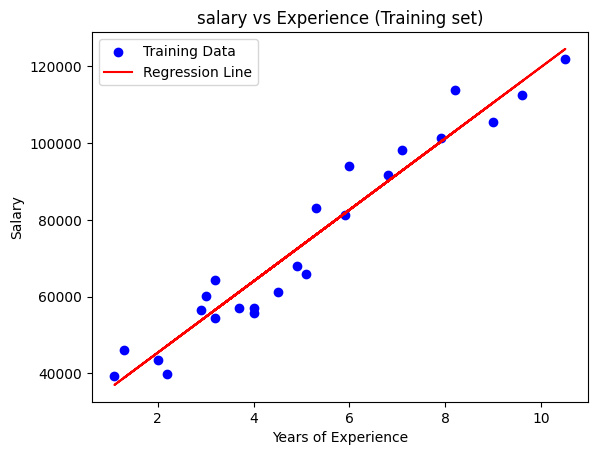

In [10]:
plt.scatter(X_train,y_train, color='blue',label='Training Data')
plt.plot(X_train, model.predict(X_train) , color='red',label='Regression Line')
plt.title('salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

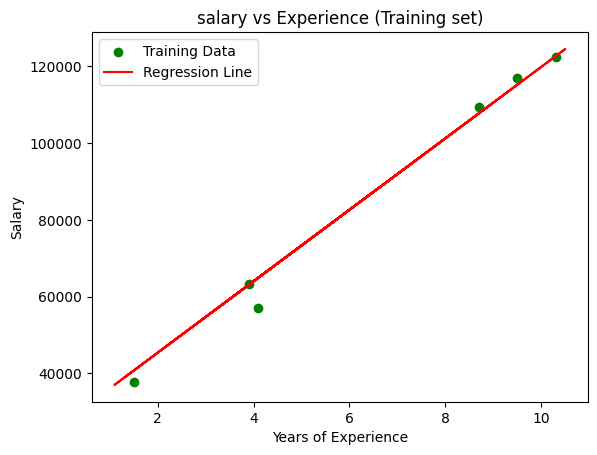

In [11]:
plt.scatter(X_test,y_test, color='green',label='Training Data')
plt.plot(X_train, model.predict(X_train) , color='red',label='Regression Line')
plt.title('salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [14]:
#plt.scatter(X,y,color='blue',label='Actual data')

experience = 5;
experience_array = np.array([[experience]])
predicted_salary = model.predict(experience_array)
predicted_salary

#plt.scatter(experience,predicted_salary,color='green',)

F:\python_env\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([73342.97478427])

In [12]:
df1 = pd.read_csv("SalaryData.csv")
df1
sc_a = StandardScaler()
sc_b = StandardScaler()

df1['YearsExperience'] = sc_a.fit_transform(df1[['YearsExperience']])
df1['Salary'] = sc_b.fit_transform(df1[['Salary']])


A = df1[['YearsExperience']]
b = df1['Salary']

mdl = LinearRegression()

mdl.fit(A,b)
A_test = sc_a.transform([[5]])

b_pred = mdl.predict(A_test)

orig_pred = sc_b.inverse_transform(b_pred.reshape(-1,1))
print(orig_pred)

[[73042.01180594]]


F:\python_env\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
F:\python_env\python\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
